**M3 - Modelagem, Avaliação e Análise de Erros - Gustavo Lobato Campos e Rafael Vinicius Tayette da Nobrega**

**Fonte dos dados:** [Kaggle - Solar Power Generation Data (anikannal)](https://www.kaggle.com/datasets/anikannal/solar-power-generation-data)

Este notebook parte da base combinada das Plantas 1 e 2 e implementa a etapa de modelagem preditiva. Foram adotadas duas trilhas sobre os mesmos atributos e o mesmo split temporal, previsão a 1h:

| Trilha | Alvo | Tipo | Métrica primária |
|---|---|---|---|
| **A** | `AC_POWER(t+1h)` — potência, kW | Regressão | RMSE |
| **B** | `EVENTO_BAIXA(t+1h)` — geração < 50% da mediana do horário | Classificação | ROC-AUC |

A Trilha B é a discretização decisória da A ("haverá déficit a ponto de exigir reserva?") e atende aos artefatos de classificação exigidos na Seção 3 (`classification_report`, matriz, ROC).

Estrutura do notebook:

0. Preparação: base consolidada, engenharia de atributos e split temporal
1. Baseline (piso de desempenho)
2. Experimentos (>= 3 abordagens, CV temporal, média ± desvio)
3. Modelo final (escolha, hiperparâmetros, avaliação no teste)
4. Análise de erros
5. Limitações

**0. Preparação**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              HistGradientBoostingRegressor, HistGradientBoostingClassifier)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_validate, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, RocCurveDisplay, f1_score)

sns.set_theme(style='whitegrid', palette='viridis')
pd.set_option('display.max_columns', None)

SEED       = 42
ALVO       = 'AC_POWER_H1'                  # AC_POWER 1h à frente
PASSO      = 15                             # min entre amostras
CORTE      = pd.Timestamp('2020-06-10')     # fronteira treino/teste
LIMIAR     = 0.50                           # evento de baixa: < 50% da mediana do slot
N_SPLITS   = 5
CLIMA      = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

rmse = lambda y, p: np.sqrt(mean_squared_error(y, p))

**0.1 Carregamento e junção das plantas**

Merge de geração × clima por `DATE_TIME`/`PLANT_ID`, com interpolação temporal dos climáticos ausentes (idêntico ao Módulo 2). Escala de `dc_max`: a Planta 1 reporta `DC_POWER` ~10× maior que a Planta 2 (arranjos de string distintos), será ajustada em 0.3.

In [2]:
def carregar(fmt_gen, plant):
    g = pd.read_csv(f'dataset/Plant_{plant}_Generation_Data.csv')
    w = pd.read_csv(f'dataset/Plant_{plant}_Weather_Sensor_Data.csv')
    g['DATE_TIME'] = pd.to_datetime(g['DATE_TIME'], format=fmt_gen)
    w['DATE_TIME'] = pd.to_datetime(w['DATE_TIME'], format='%Y-%m-%d %H:%M:%S')
    d = g.merge(w.drop(columns='SOURCE_KEY'), on=['DATE_TIME', 'PLANT_ID'], how='left').sort_values('DATE_TIME')
    d[CLIMA] = d[CLIMA].interpolate(limit_direction='both')
    d['PLANTA'] = plant
    return d

df = pd.concat([carregar('%d-%m-%Y %H:%M', 1),
                carregar('%Y-%m-%d %H:%M:%S', 2)], ignore_index=True)
df = df.sort_values(['PLANTA', 'SOURCE_KEY', 'DATE_TIME']).reset_index(drop=True)

print(f"{len(df):,} registros | {df['DATE_TIME'].min()} a {df['DATE_TIME'].max()}")
df.groupby('PLANTA').agg(registros=('AC_POWER', 'size'), inversores=('SOURCE_KEY', 'nunique'),
                         ac_max=('AC_POWER', 'max'), dc_max=('DC_POWER', 'max'))

136,476 registros | 2020-05-15 00:00:00 a 2020-06-17 23:45:00


,registros,inversores,ac_max,dc_max
PLANTA,,,,
1,68778,22,1410.95,14471.125000
2,67698,22,1385.42,1420.933333


**0.2 Engenharia de atributos**

Três decisões determinam a validade de tudo que segue:

(a) Vazamento. `AC_POWER(t)` e `DC_POWER(t)` têm correlação ≈ 1: prever `AC_POWER(t)` de `DC_POWER(t)` dá R² ≈ 0,999 e não prevê nada, só reaprende a eficiência do inversor. Por isso o alvo é deslocado para **t+1h** e todo atributo é medido em **t** ou antes.

(b) Deslocamento por *merge*, não `shift()`. A série tem lacunas; `shift(4)` deslocaria 4 *linhas*, não 4 *passos de 15 min*, corrompendo os lags (atraso ou defasagem) nas bordas. O merge sobre `DATE_TIME + Δ` é exato.

(c) Descarte de `DAILY_YIELD`/`TOTAL_YIELD`: acumuladores que dão um atalho que não sobrevive fora da janela de 34 dias.

In [3]:
CHAVE = ['PLANTA', 'SOURCE_KEY']

def deslocar(base, cols, passos, sufixo):
    """Desloca `cols` em passos*15min via merge exato (passos<0 = futuro/alvo)."""
    aux = base[CHAVE + ['DATE_TIME'] + cols].copy()
    aux['DATE_TIME'] += pd.Timedelta(minutes=PASSO * passos)
    aux = aux.rename(columns={c: c + sufixo for c in cols})
    return base.merge(aux, on=CHAVE + ['DATE_TIME'], how='left')

df = deslocar(df, ['AC_POWER'], -4, '_H1')                 # alvo: 1h à frente
for p in [1, 2, 4]:                                        # lags de potência
    df = deslocar(df, ['AC_POWER', 'DC_POWER'], p, f'_lag{p}')
df = deslocar(df, CLIMA, 4, '_lag4')                       # clima de 1h atrás

# rampas (nebulosidade em movimento) e diferença térmica
df['D_IRRAD']   = df['IRRADIATION'] - df['IRRADIATION_lag4']
df['D_AC']      = df['AC_POWER'] - df['AC_POWER_lag4']
df['D_MODTEMP'] = df['MODULE_TEMPERATURE'] - df['MODULE_TEMPERATURE_lag4']
df['DELTA_TEMP']= df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']

# janela móvel de 1h: nível e volatilidade recentes
roll = df.set_index('DATE_TIME').groupby(CHAVE)['AC_POWER'].rolling('1h')
df['AC_MEDIA_1H']  = roll.mean().to_numpy()
df['AC_DESVIO_1H'] = roll.std().fillna(0).to_numpy()

# tempo em codificação cíclica
df['MINUTO_DIA'] = df['DATE_TIME'].dt.hour * 60 + df['DATE_TIME'].dt.minute
df['HORA']       = df['DATE_TIME'].dt.hour
df['SIN_DIA']    = np.sin(2 * np.pi * df['MINUTO_DIA'] / 1440)
df['COS_DIA']    = np.cos(2 * np.pi * df['MINUTO_DIA'] / 1440)

# remove linhas com NaN em QUALQUER coluna de modelagem (inclui médias/desvios móveis,
# que o filtro por sufixo deixava passar). Lista explícita = mesmo comportamento do v10.
COLS_LIMPAR = ['AC_POWER', 'AC_POWER_lag1', 'AC_POWER_lag2', 'AC_POWER_lag4',
               'DC_POWER', 'DC_POWER_lag1', 'DC_POWER_lag2', 'DC_POWER_lag4',
               'IRRADIATION', 'IRRADIATION_lag4', 'AMBIENT_TEMPERATURE', 'AMBIENT_TEMPERATURE_lag4',
               'MODULE_TEMPERATURE', 'MODULE_TEMPERATURE_lag4', 'D_IRRAD', 'D_AC', 'D_MODTEMP',
               'DELTA_TEMP', 'AC_MEDIA_1H', 'AC_DESVIO_1H', ALVO]
antes = len(df)
df = df.dropna(subset=COLS_LIMPAR).reset_index(drop=True)
print(f"Removidas {antes - len(df):,} linhas de borda ({(antes-len(df))/antes:.2%}); restam {len(df):,}.")

Removidas 3,223 linhas de borda (2.36%); restam 133,253.


**0.3 Split temporal, normalização e evento operacional**

Split temporal (não aleatório): treino até 09/06, teste entre 10 e 17/06. Um split aleatório colocaria vizinhos de 15 min em partições opostas e a autocorrelação inflaria a métrica.

`DC_POWER` normalizada pelo máximo de treino da própria planta (decisão (c) de 0.1). O evento de baixa geração usa a mediana histórica do slot estimada só no treino, nenhuma estatística do teste entra no rótulo. Horários de mediana zero (noite) saem da Trilha B.

In [4]:
tr_mask = df['DATE_TIME'] < CORTE

# normalização de DC_POWER por planta (máximo de treino)
dc_max = df[tr_mask].groupby('PLANTA')['DC_POWER'].max()
for c in ['DC_POWER', 'DC_POWER_lag1', 'DC_POWER_lag2', 'DC_POWER_lag4']:
    df[c + '_N'] = df[c] / df['PLANTA'].map(dc_max)

# mediana de referência por (planta, slot), só treino -> define o evento de baixa
ref = df[tr_mask].groupby(['PLANTA', 'MINUTO_DIA'])['AC_POWER'].median().rename('MEDIANA')
df = df.merge(ref, on=['PLANTA', 'MINUTO_DIA'], how='left')
df['MEDIANA'] = df['MEDIANA'].fillna(0)
df['DIURNO']  = df['MEDIANA'] > 0
df['EVENTO']  = ((df[ALVO] < LIMIAR * df['MEDIANA']) & df['DIURNO']).astype(int)

ATRIBUTOS = ['AC_POWER', 'AC_POWER_lag1', 'AC_POWER_lag2', 'AC_POWER_lag4',
             'DC_POWER_N', 'DC_POWER_lag1_N', 'DC_POWER_lag2_N', 'DC_POWER_lag4_N',
             'IRRADIATION', 'IRRADIATION_lag4', 'AMBIENT_TEMPERATURE', 'AMBIENT_TEMPERATURE_lag4',
             'MODULE_TEMPERATURE', 'MODULE_TEMPERATURE_lag4', 'D_IRRAD', 'D_AC', 'D_MODTEMP',
             'DELTA_TEMP', 'AC_MEDIA_1H', 'AC_DESVIO_1H', 'SIN_DIA', 'COS_DIA', 'MINUTO_DIA',
             'PLANTA', 'MEDIANA']

treino = df[tr_mask].reset_index(drop=True)
teste  = df[~tr_mask].reset_index(drop=True)
X_tr, y_tr = treino[ATRIBUTOS], treino[ALVO]
X_te, y_te = teste[ATRIBUTOS],  teste[ALVO]

# Trilha B: só linhas diurnas
d_tr, d_te = treino[treino['DIURNO']], teste[teste['DIURNO']]
Xc_tr, yc_tr = d_tr[ATRIBUTOS], d_tr['EVENTO']
Xc_te, yc_te = d_te[ATRIBUTOS], d_te['EVENTO']

print(f"Treino {len(treino):,} | Teste {len(teste):,} | {len(ATRIBUTOS)} atributos")
print(f"Evento de baixa (diurno) — treino {yc_tr.mean():.1%}, teste {yc_te.mean():.1%}")

Treino 99,813 | Teste 33,440 | 25 atributos
Evento de baixa (diurno) — treino 30.9%, teste 36.5%


**1. Baseline**

O baseline define o piso, ou seja, o desempenho a superar para um modelo se justificar.

**Trilha A** - *persistência* (`ŷ = AC_POWER(t)`, o piso canônico de séries) e *climatologia* (`ŷ = mediana do slot`, o "modelo que só sabe a hora"). Qual vence indica onde está a informação: estado recente vs. ciclo diurno.

**Trilha B** - *classe majoritária* (nunca prevê evento; expõe porque acurácia engana sob desbalanceamento) e *persistência do evento*.

**Piso diurno.** `AC_POWER` é zero em ~metade das linhas (noite), acertadas trivialmente. O RMSE sobre a base completa é diluído por elas, por isso reporta-se também o piso diurno, a régua honesta onde o ganho do modelo precisa aparecer.

In [5]:
def metricas_reg(y, p):
    return {'RMSE': rmse(y, p), 'MAE': mean_absolute_error(y, p), 'R2': r2_score(y, p)}

pers, clim = teste['AC_POWER'], teste['MEDIANA']
base_reg = pd.DataFrame({'Persistência': metricas_reg(y_te, pers),
                         'Climatologia': metricas_reg(y_te, clim)}).T
PISO_RMSE = base_reg['RMSE'].min()

# decomposição diurno/noturno
noite = ~teste['DIURNO']
piso_periodo = pd.DataFrame({
    'Completo': [rmse(y_te, pers), rmse(y_te, clim)],
    'Diurno':   [rmse(y_te[~noite], pers[~noite]), rmse(y_te[~noite], clim[~noite])],
    'Noturno':  [rmse(y_te[noite], pers[noite]),   rmse(y_te[noite], clim[noite])],
}, index=['Persistência', 'Climatologia'])
PISO_DIURNO = piso_periodo['Diurno'].min()

print(f"AC_POWER teste: média {y_te.mean():.0f} | máx {y_te.max():.0f} kW | {noite.mean():.0%} noturno\n")
display(base_reg.round(2))
print(f"\nRMSE por período (kW):"); display(piso_periodo.round(2))
print(f">>> PISO base completa = {PISO_RMSE:.2f} kW  |  PISO diurno = {PISO_DIURNO:.2f} kW")

AC_POWER teste: média 235 | máx 1411 kW | 47% noturno



,RMSE,MAE,R2
Persistência,189.64,108.22,0.66
Climatologia,233.13,137.18,0.49



RMSE por período (kW):


,Completo,Diurno,Noturno
Persistência,189.64,259.22,18.31
Climatologia,233.13,318.89,18.31


>>> PISO base completa = 189.64 kW  |  PISO diurno = 259.22 kW


In [6]:
dummy = DummyClassifier(strategy='most_frequent').fit(Xc_tr, yc_tr)
pers_ev = (d_te['AC_POWER'] < LIMIAR * d_te['MEDIANA']).astype(int)

base_clf = pd.DataFrame({
    'Classe majoritária':   {'acurácia': (dummy.predict(Xc_te) == yc_te).mean(),
                             'F1_evento': 0.0, 'ROC_AUC': 0.5},
    'Persistência do evento':{'acurácia': (pers_ev == yc_te).mean(),
                             'F1_evento': f1_score(yc_te, pers_ev), 'ROC_AUC': roc_auc_score(yc_te, pers_ev)},
}).T
PISO_AUC = base_clf['ROC_AUC'].max()
display(base_clf.round(3))
print(f">>> PISO ROC-AUC = {PISO_AUC:.3f} (classe majoritária: acurácia alta, F1=0 — acurácia engana aqui)")

,acurácia,F1_evento,ROC_AUC
Classe majoritária,0.635,0.00,0.500
Persistência do evento,0.627,0.33,0.547


>>> PISO ROC-AUC = 0.547 (classe majoritária: acurácia alta, F1=0 — acurácia engana aqui)


**2. Experimentos**

**Validação:** `TimeSeriesSplit(5)` no treino ordenado, cada fold treina no passado, valida no futuro. `KFold` embaralhado mediria interpolação, não previsão.

**Métrica:** RMSE (penaliza os erros grandes, que na operação são os que custam). Reportado como **média ± desvio** entre folds, o desvio importa: 40±3 é preferível a 38±15.

`early_stopping=False` no boosting: ativado, ele separaria validação *aleatória* interna, vazando futuro no ajuste.

In [7]:
cv = TimeSeriesSplit(N_SPLITS)
scoring = {'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'}

modelos_reg = {
    'E1 Ridge':          make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'E2 RandomForest':   RandomForestRegressor(n_estimators=200, max_depth=16,
                                               min_samples_leaf=5, n_jobs=-1, random_state=SEED),
    'E3 HistGB':         HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                                               max_leaf_nodes=31, l2_regularization=1.0,
                                               early_stopping=False, random_state=SEED),
    'E4 HistGB profundo':HistGradientBoostingRegressor(max_iter=600, learning_rate=0.05,
                                               max_leaf_nodes=63, min_samples_leaf=40,
                                               l2_regularization=2.0, early_stopping=False, random_state=SEED),
}

linhas = []
for nome, m in modelos_reg.items():
    r = cross_validate(m, X_tr, y_tr, cv=cv, scoring=scoring)
    linhas.append({'modelo': nome, 'RMSE': -r['test_rmse'].mean(), 'RMSE_std': r['test_rmse'].std(),
                   'MAE': -r['test_mae'].mean(), 'tempo_s': r['fit_time'].mean()})
cv_reg = pd.DataFrame(linhas).sort_values('RMSE').reset_index(drop=True)
cv_reg.round(3)

,modelo,RMSE,RMSE_std,MAE,tempo_s
0,E4 HistGB profundo,124.893,64.071,54.886,6.636
1,E2 RandomForest,126.115,60.751,52.503,43.728
2,E3 HistGB,128.829,63.104,59.080,3.443
3,E1 Ridge,185.800,34.043,124.989,0.078


In [8]:
# E5: busca de hiperparâmetros na família vencedora (boosting), CV temporal
espaco = {'max_iter': [300, 500, 800], 'learning_rate': [0.03, 0.05, 0.08, 0.12],
          'max_leaf_nodes': [31, 63, 127], 'min_samples_leaf': [20, 40, 80],
          'l2_regularization': [0.0, 1.0, 5.0]}
busca = RandomizedSearchCV(HistGradientBoostingRegressor(early_stopping=False, random_state=SEED),
                           espaco, n_iter=15, cv=cv, scoring='neg_root_mean_squared_error',
                           random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)

r = cross_validate(busca.best_estimator_, X_tr, y_tr, cv=cv, scoring=scoring)
cv_reg = pd.concat([cv_reg, pd.DataFrame([{
    'modelo': 'E5 HistGB ajustado', 'RMSE': -r['test_rmse'].mean(), 'RMSE_std': r['test_rmse'].std(),
    'MAE': -r['test_mae'].mean(), 'tempo_s': r['fit_time'].mean()}])],
    ignore_index=True).sort_values('RMSE').reset_index(drop=True)

print("Melhores hiperparâmetros (E5):", busca.best_params_)
cv_reg.round(3)

Melhores hiperparâmetros (E5): {'min_samples_leaf': 80, 'max_leaf_nodes': 63, 'max_iter': 800, 'learning_rate': 0.05, 'l2_regularization': 5.0}


,modelo,RMSE,RMSE_std,MAE,tempo_s
0,E5 HistGB ajustado,124.459,63.013,56.122,8.874
1,E4 HistGB profundo,124.893,64.071,54.886,6.636
2,E2 RandomForest,126.115,60.751,52.503,43.728
3,E3 HistGB,128.829,63.104,59.080,3.443
4,E1 Ridge,185.800,34.043,124.989,0.078


In [9]:
modelos_clf = {
    'C1 Logística':    make_pipeline(StandardScaler(),
                          LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)),
    'C2 RandomForest': RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_leaf=5,
                          class_weight='balanced', n_jobs=-1, random_state=SEED),
    'C3 HistGB':       HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                          max_leaf_nodes=31, l2_regularization=1.0, early_stopping=False, random_state=SEED),
}

linhas = []
for nome, m in modelos_clf.items():
    r = cross_validate(m, Xc_tr, yc_tr, cv=cv, scoring={'auc': 'roc_auc', 'f1': 'f1'})
    linhas.append({'modelo': nome, 'ROC_AUC': r['test_auc'].mean(), 'AUC_std': r['test_auc'].std(),
                   'F1_evento': r['test_f1'].mean(), 'F1_std': r['test_f1'].std()})
cv_clf = pd.DataFrame(linhas).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
cv_clf.round(3)

,modelo,ROC_AUC,AUC_std,F1_evento,F1_std
0,C2 RandomForest,0.960,0.057,0.877,0.118
1,C3 HistGB,0.958,0.062,0.883,0.120
2,C1 Logística,0.927,0.030,0.792,0.005


**2.1 Justificativa das abordagens**

| Run | Modelo | Por quê |
|---|---|---|
| E1 | Ridge | Testa a linearidade. Se empata com o boosting, a não linearidade é dispensável. Regularização controla a colinearidade entre lags. |
| E2 | Random Forest | Bagging: baixa variância, captura interações e o piso em zero sem transformar o alvo. Controle contra o boosting. |
| E3 | HistGB | Boosting histogramizado, referência tabular. Configuração conservadora. |
| E4 | HistGB profundo | Testa se mais capacidade ajuda ou memoriza os 26 dias. E3×E4 é o diagnóstico de sobreajuste. |
| E5 | HistGB ajustado | Busca aleatória (15 amostras) na família vencedora, cobre o espaço melhor que grade exaustiva com poucos hiperparâmetros dominantes. |
| C1–C3 | Logística / RF / HistGB | Espelham E1–E3 na trilha binária, mantendo a comparação sobre as mesmas famílias. `class_weight='balanced'` corrige o desbalanceamento. |

**3. Modelo final**

Critérios, nesta ordem: (1) RMSE de CV; (2) desvio entre folds (estabilidade); (3) custo/simplicidade, para desempate quando (1) e (2) diferem menos que 1 desvio. Reajuste no treino completo, avaliação única no teste.

In [10]:
mapa = dict(modelos_reg); mapa['E5 HistGB ajustado'] = busca.best_estimator_
melhor = cv_reg.iloc[0]['modelo']
final = mapa[melhor]

margem = cv_reg.iloc[1]['RMSE'] - cv_reg.iloc[0]['RMSE']
print(f"Melhor por CV: {melhor} | RMSE {cv_reg.iloc[0]['RMSE']:.2f} ± {cv_reg.iloc[0]['RMSE_std']:.2f}")
print(f"Vantagem sobre o 2º: {margem:.2f} kW ({'>' if margem > cv_reg.iloc[0]['RMSE_std'] else '<'} 1 desvio "
      f"-> {'sustentada pelo desempenho' if margem > cv_reg.iloc[0]['RMSE_std'] else 'desempate por simplicidade'})")

final.fit(X_tr, y_tr)
pred_te = np.clip(final.predict(X_te), 0, None)      # potência não é negativa
m = metricas_reg(y_te, pred_te)
print(f"\nTESTE — RMSE {m['RMSE']:.2f} | MAE {m['MAE']:.2f} | R² {m['R2']:.3f}")
print(f"Redução sobre o piso: {1 - m['RMSE']/PISO_RMSE:.1%} (completa) | {1 - m['RMSE']/PISO_DIURNO:.1%} (diurna)")

Melhor por CV: E5 HistGB ajustado | RMSE 124.46 ± 63.01
Vantagem sobre o 2º: 0.43 kW (< 1 desvio -> desempate por simplicidade)

TESTE — RMSE 150.49 | MAE 75.11 | R² 0.787
Redução sobre o piso: 20.6% (completa) | 41.9% (diurna)


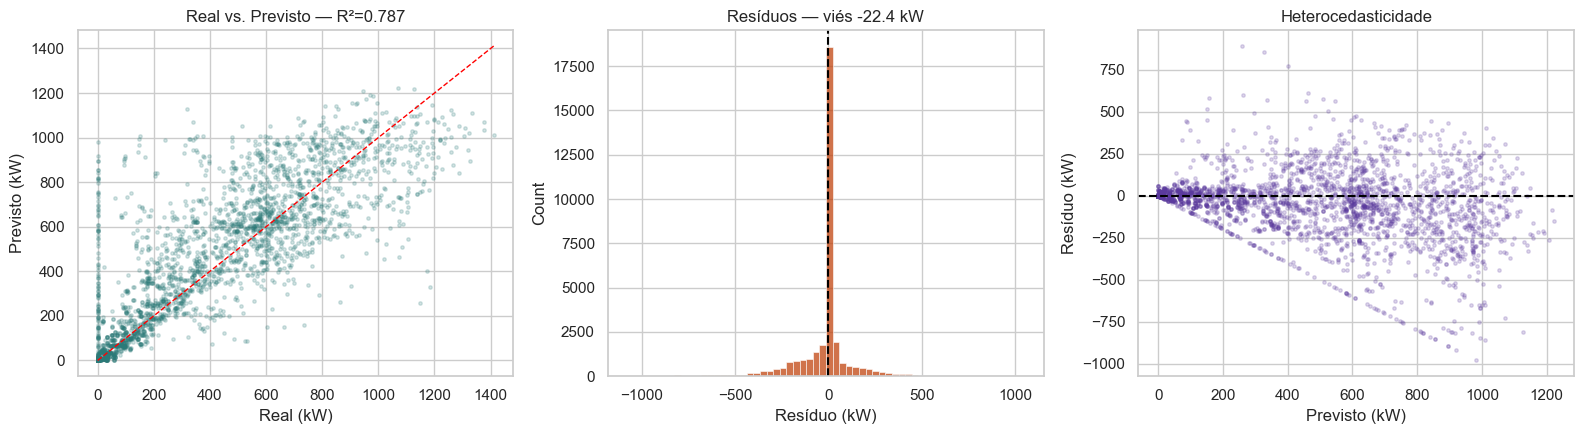

In [11]:
residuo = y_te.values - pred_te
amostra = np.random.default_rng(SEED).choice(len(y_te), min(5000, len(y_te)), replace=False)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].scatter(y_te.values[amostra], pred_te[amostra], s=6, alpha=0.2, color='#2b7a78')
ax[0].plot([0, y_te.max()], [0, y_te.max()], 'r--', lw=1)
ax[0].set(xlabel='Real (kW)', ylabel='Previsto (kW)', title=f"Real vs. Previsto — R²={m['R2']:.3f}")

sns.histplot(residuo, bins=60, ax=ax[1], color='#c1440e')
ax[1].axvline(0, color='k', ls='--'); ax[1].set(xlabel='Resíduo (kW)',
    title=f"Resíduos — viés {residuo.mean():+.1f} kW")

ax[2].scatter(pred_te[amostra], residuo[amostra], s=6, alpha=0.2, color='#5b3a9e')
ax[2].axhline(0, color='k', ls='--')
ax[2].set(xlabel='Previsto (kW)', ylabel='Resíduo (kW)', title='Heterocedasticidade')
plt.tight_layout(); plt.show()

**Trilha B — modelo final e artefatos da Seção 3** (`classification_report`, matriz, ROC).

In [12]:
melhor_clf = cv_clf.iloc[0]['modelo']
clf = modelos_clf[melhor_clf].fit(Xc_tr, yc_tr)
proba = clf.predict_proba(Xc_te)[:, 1]
pred_clf = (proba >= 0.5).astype(int)
auc = roc_auc_score(yc_te, proba)

print(f"Modelo final Trilha B: {melhor_clf}\n")
print(classification_report(yc_te, pred_clf, target_names=['Normal', 'Baixa geração'], digits=3))
print(f"ROC-AUC {auc:.3f} (piso {PISO_AUC:.3f})")

Modelo final Trilha B: C2 RandomForest

               precision    recall  f1-score   support

       Normal      0.854     0.908     0.880     11321
Baixa geração      0.820     0.728     0.772      6499

     accuracy                          0.843     17820
    macro avg      0.837     0.818     0.826     17820
 weighted avg      0.841     0.843     0.840     17820

ROC-AUC 0.914 (piso 0.547)


c:\Users\lobat\OneDrive\1 - Trampo\09 - Drive - Lobato.Prof\Pós UNIMONTES\07 Machine Learning\Trabalho 3\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


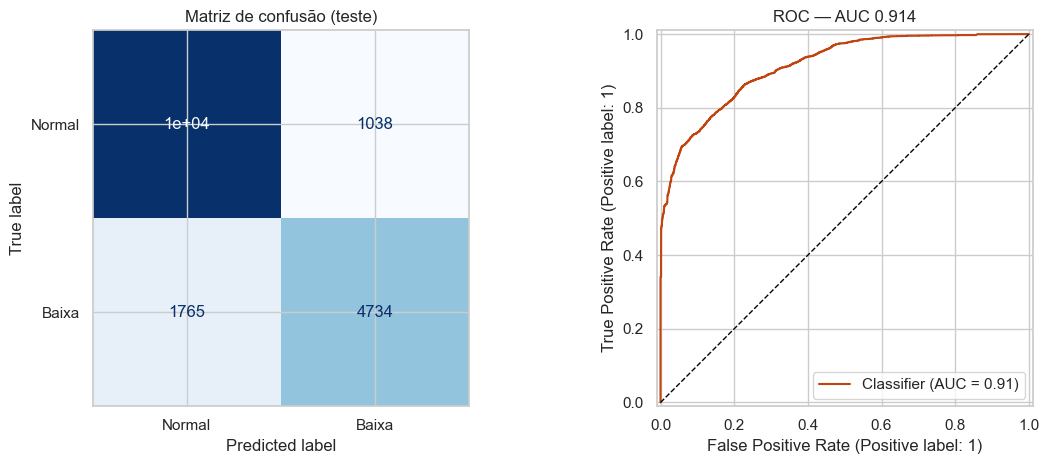

VP 4734 | FN 1765 (déficit não previsto — custo alto) | FP 1038 (reserva ociosa)
Recall 72.8% | Precisão 82.0%


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
cm = confusion_matrix(yc_te, pred_clf)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Baixa']).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Matriz de confusão (teste)')
RocCurveDisplay.from_predictions(yc_te, proba, ax=ax[1], color='#c1440e')
ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
ax[1].set_title(f'ROC — AUC {auc:.3f}')
plt.tight_layout(); plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"VP {vp} | FN {fn} (déficit não previsto — custo alto) | FP {fp} (reserva ociosa)")
print(f"Recall {vp/(vp+fn):.1%} | Precisão {vp/(vp+fp):.1%}")

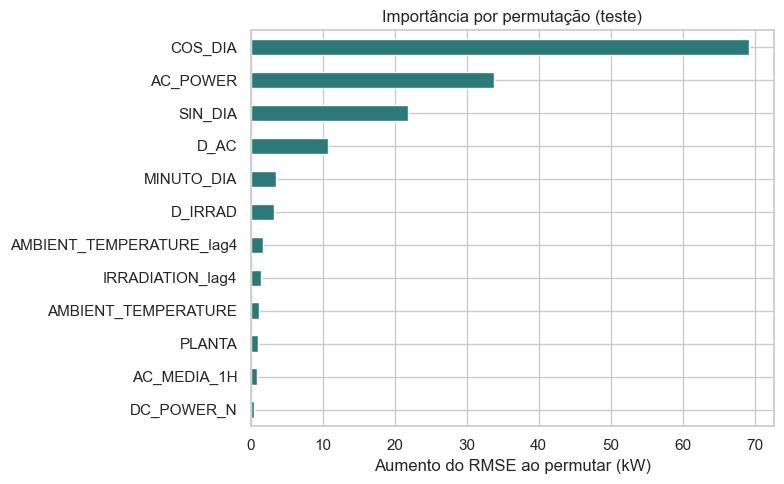

In [14]:
# Importância por permutação (Trilha A): degradação do RMSE ao embaralhar cada atributo
sub = np.random.default_rng(SEED).choice(len(X_te), min(4000, len(X_te)), replace=False)
imp = permutation_importance(final, X_te.iloc[sub], y_te.iloc[sub], n_repeats=5,
                             scoring='neg_root_mean_squared_error', random_state=SEED, n_jobs=-1)
top = (pd.Series(imp.importances_mean, index=ATRIBUTOS)
       .sort_values(ascending=False).head(12))

plt.figure(figsize=(8, 5))
top[::-1].plot.barh(color='#2b7a78')
plt.xlabel('Aumento do RMSE ao permutar (kW)'); plt.title('Importância por permutação (teste)')
plt.tight_layout(); plt.show()

### 3.1 Escolha — *preencher após leitura das saídas*

O modelo final é **[modelo]**, com **[hiperparâmetros]**. RMSE de CV **[X ± Y]** contra **[Z]** do 2º; a diferença **[é/não é]** > 1 desvio. Ganho de **[N]%** sobre o piso. Na Trilha B, **[modelo]** atinge ROC-AUC **[A]** contra **[piso]**.

**4. Análise de erros**

RMSE agregado esconde a estrutura do erro. Decomposição por hora, irradiância, rampa, planta e inversor.

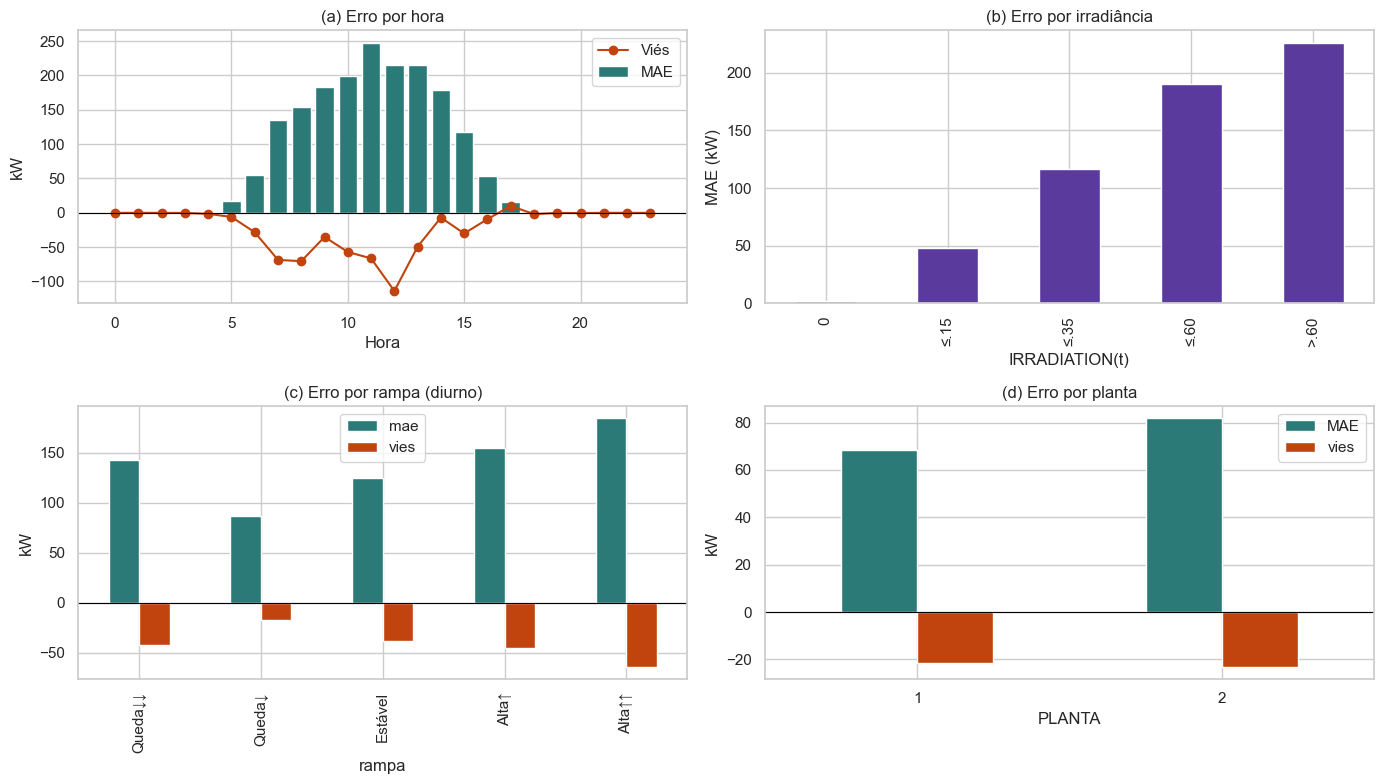

In [15]:
erro = teste[['PLANTA', 'SOURCE_KEY', 'HORA', 'IRRADIATION', 'D_IRRAD', 'DIURNO']].copy()
erro['residuo'] = y_te.values - pred_te
erro['abs'] = erro['residuo'].abs()

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# (a) por hora
h = erro.groupby('HORA').agg(mae=('abs', 'mean'), vies=('residuo', 'mean'))
ax[0,0].bar(h.index, h['mae'], color='#2b7a78', label='MAE')
ax[0,0].plot(h.index, h['vies'], 'o-', color='#c1440e', label='Viés')
ax[0,0].axhline(0, color='k', lw=.8); ax[0,0].legend()
ax[0,0].set(xlabel='Hora', ylabel='kW', title='(a) Erro por hora')

# (b) por faixa de irradiância
erro['faixa'] = pd.cut(erro['IRRADIATION'], [-.01, .001, .15, .35, .6, 1.5],
                       labels=['0', '≤.15', '≤.35', '≤.60', '>.60'])
erro.groupby('faixa', observed=True)['abs'].mean().plot.bar(ax=ax[0,1], color='#5b3a9e')
ax[0,1].set(xlabel='IRRADIATION(t)', ylabel='MAE (kW)', title='(b) Erro por irradiância')

# (c) por rampa (diurno)
erro['rampa'] = pd.cut(erro['D_IRRAD'], [-2, -.15, -.03, .03, .15, 2],
                       labels=['Queda↓↓', 'Queda↓', 'Estável', 'Alta↑', 'Alta↑↑'])
rp = erro[erro['DIURNO']].groupby('rampa', observed=True).agg(mae=('abs', 'mean'), vies=('residuo', 'mean'))
rp.plot.bar(ax=ax[1,0], color=['#2b7a78', '#c1440e'])
ax[1,0].axhline(0, color='k', lw=.8); ax[1,0].set(ylabel='kW', title='(c) Erro por rampa (diurno)')

# (d) por planta
erro.groupby('PLANTA').agg(MAE=('abs', 'mean'), vies=('residuo', 'mean')).plot.bar(
    ax=ax[1,1], color=['#2b7a78', '#c1440e'])
ax[1,1].axhline(0, color='k', lw=.8); ax[1,1].set(title='(d) Erro por planta', ylabel='kW')
ax[1,1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

In [16]:
# concentração do erro e contraste diurno/noturno
e2 = np.sort(erro['residuo'].values ** 2)[::-1]
frac = np.cumsum(e2) / e2.sum()
for p in [0.05, 0.10, 0.25]:
    print(f"{p:.0%} das obs. com maior erro concentram {frac[int(p*len(e2))-1]:.0%} do erro quadrático")

print(f"\nMAE noturno {erro[~erro['DIURNO']]['abs'].mean():.1f} kW | "
      f"diurno {erro[erro['DIURNO']]['abs'].mean():.1f} kW")

# inversores com maior erro sistemático (viés negativo = modelo superestima a unidade)
piores = (erro[erro['DIURNO']].groupby(['PLANTA', 'SOURCE_KEY'])
          .agg(MAE=('abs', 'mean'), vies=('residuo', 'mean'))
          .sort_values('MAE', ascending=False).head(6))
print("\nInversores com maior MAE diurno:"); display(piores.round(2))

5% das obs. com maior erro concentram 59% do erro quadrático
10% das obs. com maior erro concentram 78% do erro quadrático
25% das obs. com maior erro concentram 97% do erro quadrático

MAE noturno 1.7 kW | diurno 139.4 kW

Inversores com maior MAE diurno:


MAE   vies
PLANTA SOURCE_KEY                    
2      Qf4GUc1pJu5T6c6  165.85 -63.11
       4UPUqMRk7TRMgml  163.26 -53.82
       Mx2yZCDsyf6DPfv  161.84 -60.14
       oZ35aAeoifZaQzV  161.40 -59.15
       mqwcsP2rE7J0TFp  158.03 -31.00
       NgDl19wMapZy17u  157.00 -38.27

,n,hora,irrad,rampa
tipo,,,,
FN,1765,12.688,0.432,-0.045
FP,1038,12.636,0.373,-0.071
VN,10283,9.841,0.404,0.064
VP,4734,16.002,0.195,-0.097


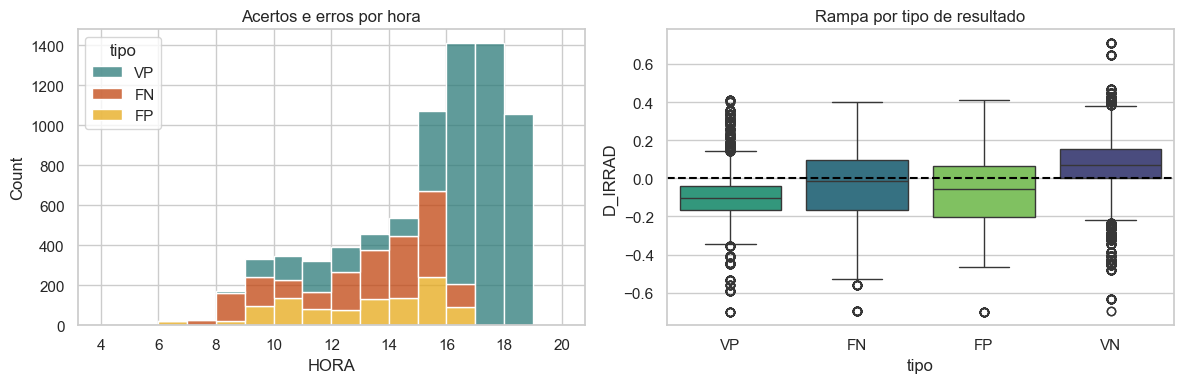

In [17]:
# Trilha B: onde erra — caracterização de VP/FN/FP
diag = d_te[['HORA', 'IRRADIATION', 'D_IRRAD']].copy()
diag['tipo'] = np.select(
    [(yc_te.values == 1) & (pred_clf == 1), (yc_te.values == 1) & (pred_clf == 0),
     (yc_te.values == 0) & (pred_clf == 1)], ['VP', 'FN', 'FP'], default='VN')

display(diag.groupby('tipo').agg(n=('HORA', 'size'), hora=('HORA', 'mean'),
        irrad=('IRRADIATION', 'mean'), rampa=('D_IRRAD', 'mean')).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=diag, x='HORA', hue='tipo', hue_order=['VP', 'FN', 'FP'],
             multiple='stack', bins=range(4, 21), ax=ax[0], palette=['#2b7a78', '#c1440e', '#e6a817'])
ax[0].set_title('Acertos e erros por hora')
sns.boxplot(data=diag, x='tipo', y='D_IRRAD', order=['VP', 'FN', 'FP', 'VN'],
            hue='tipo', legend=False, ax=ax[1], palette='viridis')
ax[1].axhline(0, color='k', ls='--'); ax[1].set_title('Rampa por tipo de resultado')
plt.tight_layout(); plt.show()

**4.1 Interpretação** *preencher após leitura das saídas*

**Onde erra mais.** O erro é **[concentrado/distribuído]**: **[N]%** das obs. respondem por **[M]%** do erro quadrático. Quase todo o erro é diurno (MAE noturno **[x]** vs. diurno **[y]** kW) — logo, RMSE sobre a base completa superestima o modelo; a métrica relevante é a diurna.

**Padrão.** O MAE **[cresce/não muda]** sob rampa forte; o viés é **[sinal]** — o modelo **[sub/super]**estima quando a nebulosidade muda. Na Trilha B, os FN concentram-se em **[condição]** (início súbito de nebulosidade, que o estado presente não antecipa).

**Significado no domínio.** (1) Erro em rampa é o que custa — em regime estável a persistência já resolve. (2) Assimetria **[FN]** vs. **[FP]**: um FN é déficit não antecipado (reserva não despachada); o limiar de 0,5 **não é o ótimo** e pode ser deslocado pela ROC sem reajustar o modelo. (3) Viés negativo por inversor sugere degradação de hardware — é o gancho para o detector de anomalia (Módulo 4).

**5. Limitações**

Cada item é uma **condição de treino** seguida do que ela **limita**.

**5.1 34 dias, uma estação** (pré-monção/monção, sul da Índia). Limita afirmações sobre desempenho anual: a métrica vale para junho/2020 nessas duas usinas, não para "previsão fotovoltaica" em geral.

**5.2 Split único, teste de 7 dias.** O intervalo de confiança da métrica de teste é desconhecido — sete dias podem ter sido atípicos.

**5.3 Clima *observado*, não *previsto*.** Atributos climáticos são medidos em `t`. Em produção isso entrega previsão a 1h, mas **não** a 4–6h (despacho intradiário exigiria NWP como entrada, cuja incerteza passaria a dominar). É o limite mais sério para uso operacional.

**5.4 Um sensor meteorológico por planta**, atribuído a todos os inversores. Sombreamento parcial e sujidade localizada são invisíveis — o modelo não distingue "nuvem sobre o inversor X" de "inversor X degradado".

**5.5 Inversores intercambiáveis.** `SOURCE_KEY` foi excluído para não confundir identidade com condição; em troca, o erro por inversor mistura heterogeneidade real com erro de previsão.

**5.6 Escala de `DC_POWER`.** A normalização por planta é correção de escala, não reconciliação física; as importâncias de `DC_POWER_N` não têm interpretação física direta entre plantas.

**5.7 Limiar de 50% do evento** é escolha do analista. O ROC-AUC é robusto ao limiar de *decisão*, não ao de *definição do rótulo* — antes de operacionalizar, derivar do custo real de despacho.

**5.8 Interpolação linear** dos climáticos suaviza a irradiância justamente no regime de nebulosidade intermitente, onde o modelo mais erra.

**5.9 Sem covariáveis de manutenção** (limpeza, curtailment, indisponibilidade). Parte do resíduo pode ser evento operacional determinístico, não erro do modelo — o teto alcançável com estes dados é menor que o teto físico.

**5.10 Não negatividade via `clip`** aplicada a posteriori. Modelar `log1p(AC_POWER)`, perda Tweedie ou modelo em dois estágios não foi testado.

---